In [1]:
!pip install matplotlib torch transformers datasets evaluate matplotlib pandas tqdm scikit-learn

In [2]:
import os
import json
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from datetime import datetime
from tqdm.auto import tqdm
import torch
from torch.optim import AdamW
from torch.utils.data import DataLoader
from datasets import load_dataset
import evaluate
from transformers import (
    BertTokenizerFast,
    BertForQuestionAnswering,
    get_linear_schedule_with_warmup,
    default_data_collator,
)
from transformers.trainer_utils import get_last_checkpoint

BERT_DIR = os.getcwd()

# Training configuration
BATCH_SIZE = 8
GRADIENT_ACCUMULATION_STEPS = 4
LEARNING_RATE = 2e-5
WEIGHT_DECAY = 0.01
WARMUP_RATIO = 0.1
NUM_EPOCHS = 3
MAX_SEQ_LENGTH = 384
DOC_STRIDE = 128
MAX_QUERY_LENGTH = 64

# File paths
MODEL_DIR = os.path.join(BERT_DIR, "bert_squad2_finetuned")
METRICS_FILE = os.path.join(BERT_DIR, "training_metrics.json")
TRAINING_STATE_FILE = os.path.join(MODEL_DIR, "training_state.pt")

# Create directories if they don't exist
os.makedirs(MODEL_DIR, exist_ok=True)

# Set device
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Using device: {device}")

# Initialize metrics history
metrics_history = {
    "train_loss": [],
    "eval_loss": [],
    "exact": [],
    "f1": []
}

# Function to get the last checkpoint
def get_last_checkpoint(model_dir):
    checkpoints = [d for d in os.listdir(model_dir) if d.startswith("checkpoint-")]
    if not checkpoints:
        return None
    return os.path.join(model_dir, max(checkpoints, key=lambda x: int(x.split("-")[1])))

/Users/seanhall/Desktop/NLPFinalProject/.venv/lib/python3.13/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


Using device: cpu


In [3]:
# =============================================================
# CELL 2: Data Loading and Preprocessing
# =============================================================
print("Loading SQuAD 2.0 dataset")
squad_dataset = load_dataset("squad_v2", trust_remote_code=True)
tokenizer = BertTokenizerFast.from_pretrained("bert-base-uncased")

# Define constants for preprocessing
MAX_LENGTH = 384  # Maximum sequence length
DOC_STRIDE = 128  # Stride for sliding window

def preprocess_training_examples(examples):
    questions = [q.strip() for q in examples["question"]]
    contexts = [c.strip() for c in examples["context"]]
    inputs = tokenizer(
        questions,
        contexts,
        max_length=MAX_LENGTH,
        truncation="only_second",
        stride=DOC_STRIDE,
        return_overflowing_tokens=True,
        return_offsets_mapping=True,
        padding="max_length",
    )

    offset_mapping = inputs.pop("offset_mapping")
    sample_map = inputs.pop("overflow_to_sample_mapping")
    start_positions = []
    end_positions = []

    for i, offset in enumerate(offset_mapping):
        sample_idx = sample_map[i]
        question_start_idx = len(tokenizer(questions[sample_idx], add_special_tokens=False)["input_ids"])
        question_end_idx = inputs["input_ids"][i].index(tokenizer.sep_token_id)
        
        # Set default values for no answer
        start_position = question_end_idx
        end_position = question_end_idx
        
        # Handle SQuAD 2.0's answer format
        answer = examples["answers"][sample_idx]
        if answer["text"]:  # If there is an answer
            ans_start = answer["answer_start"][0]
            ans_end = ans_start + len(answer["text"][0])
            
            # Find token indices that contain the answer
            for j, (token_start, token_end) in enumerate(offset):
                if j <= question_end_idx:  # Skip question tokens
                    continue
                if token_start <= ans_start and ans_end <= token_end:
                    start_position = j
                    end_position = j
                    break
                if token_start <= ans_start < token_end:
                    start_position = j
                if token_start < ans_end <= token_end:
                    end_position = j
                    break
        
        start_positions.append(start_position)
        end_positions.append(end_position)
    
    inputs["start_positions"] = start_positions
    inputs["end_positions"] = end_positions
    return inputs

def preprocess_validation_examples(examples):
    questions = [q.strip() for q in examples["question"]]
    contexts = [c.strip() for c in examples["context"]]
    inputs = tokenizer(
        questions,
        contexts,
        max_length=MAX_LENGTH,
        truncation="only_second",
        stride=DOC_STRIDE,
        return_overflowing_tokens=True,
        return_offsets_mapping=True,
        padding="max_length",
    )

    sample_map = inputs.pop("overflow_to_sample_mapping")
    example_ids = []

    for i in range(len(inputs["input_ids"])):
        sample_idx = sample_map[i]
        example_ids.append(examples["id"][sample_idx])
    
    inputs["example_id"] = example_ids
    return inputs

# Process datasets
print("Processing training data...")
train_dataset = squad_dataset["train"].map(
    preprocess_training_examples,
    batched=True,
    remove_columns=squad_dataset["train"].column_names,
)

print("Processing validation data...")
validation_dataset = squad_dataset["validation"].map(
    preprocess_validation_examples,
    batched=True,
    remove_columns=squad_dataset["validation"].column_names,
)

train_dataset.set_format(type="torch", columns=["input_ids", "attention_mask", "start_positions", "end_positions"])
validation_set_for_training = validation_dataset.remove_columns(["offset_mapping", "example_id"])
validation_set_for_training.set_format(type="torch", columns=["input_ids", "attention_mask"])

print(f"Training samples: {len(train_dataset)}, Validation samples: {len(validation_dataset)}")

Loading SQuAD 2.0 dataset
Processing training data...
Processing validation data...
Training samples: 131754, Validation samples: 12134


In [4]:
# =============================================================
# CELL 3: Model Setup and Training Configuration
# =============================================================
# Path to your existing fine-tuned model - using specific checkpoint
checkpoint_path = "/Users/seanhall/Desktop/NLPFinalProject/bert_squad2_finetuned/checkpoint-82350"

# Initialize model by loading from your specific checkpoint
print(f"Loading fine-tuned model from checkpoint: {checkpoint_path}")
try:
    # First verify the checkpoint exists and has the required files
    if not os.path.exists(checkpoint_path):
        raise FileNotFoundError(f"Checkpoint directory not found: {checkpoint_path}")
    
    required_files = ["config.json", "model.safetensors", "tokenizer.json"]
    for file in required_files:
        if not os.path.exists(os.path.join(checkpoint_path, file)):
            raise FileNotFoundError(f"Required file not found: {file}")
    
    # Load the model and tokenizer
    model = BertForQuestionAnswering.from_pretrained(
        checkpoint_path,
        local_files_only=True,
        ignore_mismatched_sizes=True,
        use_safetensors=True
    )
    tokenizer = BertTokenizerFast.from_pretrained(
        checkpoint_path,
        local_files_only=True
    )
    print("Successfully loaded model and tokenizer from checkpoint")
except Exception as e:
    print(f"Error loading model: {e}")
    raise  # Raise the error instead of falling back to base model

model.to(device)

# Prepare optimizer and learning rate scheduler
optimizer = AdamW(model.parameters(), lr=LEARNING_RATE, weight_decay=WEIGHT_DECAY)

# Calculate training steps
steps_per_epoch = len(train_dataset) // (BATCH_SIZE * GRADIENT_ACCUMULATION_STEPS)
total_training_steps = steps_per_epoch * NUM_EPOCHS
warmup_steps = int(total_training_steps * WARMUP_RATIO)

scheduler = get_linear_schedule_with_warmup(
    optimizer,
    num_warmup_steps=warmup_steps,
    num_training_steps=total_training_steps
)

print(f"Steps per epoch: {steps_per_epoch}")
print(f"Total training steps: {total_training_steps}")
print(f"Warmup steps: {warmup_steps}")

# Initialize training state variables
start_epoch = 0
global_step = 0

# Recover training state if available
training_state_path = os.path.join(checkpoint_path, "trainer_state.json")
if os.path.exists(training_state_path):
    try:
        with open(training_state_path, 'r') as f:
            training_state = json.load(f)
        start_epoch = training_state.get("epoch", 0)
        global_step = training_state.get("global_step", 0)
        print(f"Resumed from epoch {start_epoch}, step {global_step}")
    except Exception as e:
        print(f"Could not load training state: {e}")
        print("Starting from current checkpoint")

# Load existing metrics history
if os.path.exists(METRICS_FILE):
    try:
        with open(METRICS_FILE, 'r') as f:
            metrics_history = json.load(f)
        print("Loaded existing metrics history")
    except Exception as e:
        print(f"Could not load metrics history: {e}")
        print("Starting fresh")

Loading fine-tuned model from checkpoint: /Users/seanhall/Desktop/NLPFinalProject/bert_squad2_finetuned/checkpoint-82350
Successfully loaded model and tokenizer from checkpoint
Steps per epoch: 4117
Total training steps: 12351
Warmup steps: 1235
Resumed from epoch 5.0, step 82350


In [5]:
squad_metric = evaluate.load("squad_v2")

def postprocess_qa_predictions(examples, features, raw_predictions, n_best_size=20, max_answer_length=30):
    all_start_logits, all_end_logits = raw_predictions
    example_id_to_index = {k: i for i, k in enumerate(examples["id"])}
    features_per_example = collections.defaultdict(list)
    
    for i, feature in enumerate(features):
        features_per_example[feature["example_id"]].append(i)
    
    predictions = collections.OrderedDict()
    
    for example_id, example_index in example_id_to_index.items():
        example = examples[example_index]
        features_indices = features_per_example[example_id]
        
        min_null_score = float('inf')
        valid_answers = []
        
        for feature_index in features_indices:
            start_logits = all_start_logits[feature_index]
            end_logits = all_end_logits[feature_index]
            offset_mapping = features[feature_index]["offset_mapping"]
            
            start_idx = features[feature_index]["input_ids"].index(tokenizer.sep_token_id) + 1
            end_idx = len(features[feature_index]["input_ids"]) - 1
            
            # Get the minimum null prediction score
            feature_null_score = start_logits[start_idx] + end_logits[start_idx]
            if feature_null_score < min_null_score:
                min_null_score = feature_null_score
            
            # Go through all possibilities for the n_best_size answers
            start_indexes = np.argsort(start_logits[start_idx:end_idx])[-n_best_size:].tolist()
            end_indexes = np.argsort(end_logits[start_idx:end_idx])[-n_best_size:].tolist()
            
            for start_index in start_indexes:
                for end_index in end_indexes:
                    # Don't consider out-of-scope answers
                    if (
                        start_index + start_idx >= end_index + start_idx
                        or end_index + start_idx >= len(offset_mapping)
                        or offset_mapping[start_index + start_idx] is None
                        or offset_mapping[end_index + start_idx] is None
                    ):
                        continue
                    
                    # Don't consider answers with a length > max_answer_length
                    if end_index + start_idx - (start_index + start_idx) + 1 > max_answer_length:
                        continue
                    
                    answer = {
                        "text": example["context"][
                            offset_mapping[start_index + start_idx][0]:offset_mapping[end_index + start_idx][1]
                        ],
                        "logit_score": start_logits[start_index + start_idx] + end_logits[end_index + start_idx],
                    }
                    valid_answers.append(answer)
        
        if len(valid_answers) > 0:
            best_answer = sorted(valid_answers, key=lambda x: x["logit_score"], reverse=True)[0]
            predictions[example_id] = {
                "prediction_text": best_answer["text"],
                "no_answer_probability": min_null_score / (best_answer["logit_score"] + 1e-8),
            }
        else:
            predictions[example_id] = {"prediction_text": "", "no_answer_probability": 1.0}
    
    return predictions

def evaluate_model(model, validation_dataset, examples):
    model.eval()
    all_start_logits = []
    all_end_logits = []
    
    validation_dataloader = DataLoader(
        validation_set_for_training,
        batch_size=BATCH_SIZE,
        collate_fn=default_data_collator,
        shuffle=False
    )
    
    for batch in tqdm(validation_dataloader, desc="Evaluating"):
        batch = {k: v.to(device) for k, v in batch.items()}
        with torch.no_grad():
            outputs = model(**batch)
        
        start_logits = outputs.start_logits.cpu().numpy()
        end_logits = outputs.end_logits.cpu().numpy()
        
        all_start_logits.extend(start_logits)
        all_end_logits.extend(end_logits)
    
    # Prepare validation features for postprocessing
    validation_features = [
        {
            "input_ids": validation_dataset[i]["input_ids"],
            "offset_mapping": validation_dataset[i]["offset_mapping"],
            "example_id": validation_dataset[i]["example_id"],
        }
        for i in range(len(validation_dataset))
    ]
    
    predictions = postprocess_qa_predictions(
        squad_dataset["validation"],
        validation_features,
        (all_start_logits, all_end_logits)
    )
    
    formatted_predictions = [
        {"id": k, "prediction_text": v["prediction_text"], "no_answer_probability": v["no_answer_probability"]}
        for k, v in predictions.items()
    ]
    
    references = [
        {"id": ex["id"], "answers": ex["answers"]}
        for ex in squad_dataset["validation"]
    ]
    
    metrics = squad_metric.compute(predictions=formatted_predictions, references=references)
    
    return metrics

In [7]:
import collections  # Add this import for postprocessing

# Create data loaders
train_dataloader = DataLoader(
    train_dataset,
    batch_size=BATCH_SIZE,
    shuffle=True,
    collate_fn=default_data_collator,
)

# Variables to track best model
best_metric = 0.0

# Convert start_epoch to integer and calculate end_epoch
start_epoch = int(start_epoch)
end_epoch = start_epoch + NUM_EPOCHS  # Train for NUM_EPOCHS more epochs from the current epoch

# Resume or start training loop
print(f"Starting training for {NUM_EPOCHS} epochs, from epoch {start_epoch+1} to {end_epoch}")

for epoch in range(start_epoch, end_epoch):
    model.train()
    total_loss = 0
    progress_bar = tqdm(train_dataloader, desc=f"Epoch {epoch+1}/{end_epoch}")
    
    for step, batch in enumerate(progress_bar):
        batch = {k: v.to(device) for k, v in batch.items()}
        outputs = model(**batch)
        loss = outputs.loss
        
        # Normalize loss for gradient accumulation
        loss = loss / GRADIENT_ACCUMULATION_STEPS
        loss.backward()
        
        # Update parameters after accumulating gradients
        if (step + 1) % GRADIENT_ACCUMULATION_STEPS == 0:
            optimizer.step()
            scheduler.step()
            optimizer.zero_grad()
            global_step += 1
            
            # Log training loss
            total_loss += loss.item() * GRADIENT_ACCUMULATION_STEPS
            progress_bar.set_postfix({"loss": loss.item() * GRADIENT_ACCUMULATION_STEPS})
            
            # Track metrics
            if global_step % 100 == 0:
                if "training_loss" not in metrics_history:
                    metrics_history["training_loss"] = []
                if "learning_rate" not in metrics_history:
                    metrics_history["learning_rate"] = []
                if "steps" not in metrics_history:
                    metrics_history["steps"] = []
                if "epochs" not in metrics_history:
                    metrics_history["epochs"] = []
                
                metrics_history["training_loss"].append(loss.item() * GRADIENT_ACCUMULATION_STEPS)
                metrics_history["learning_rate"].append(scheduler.get_last_lr()[0])
                metrics_history["steps"].append(global_step)
                metrics_history["epochs"].append(epoch + step / len(train_dataloader))
                
                # Save metrics
                with open(METRICS_FILE, 'w') as f:
                    json.dump(metrics_history, f, indent=2)
            
            # Evaluate and save model
            EVAL_STEPS = 500  # Define EVAL_STEPS if not defined
            if global_step % EVAL_STEPS == 0:
                print(f"\nEvaluating at step {global_step}...")
                eval_metrics = evaluate_model(model, validation_dataset, squad_dataset["validation"])
                
                # Print metrics
                print(f"Exact Match: {eval_metrics['exact']:.2f}")
                print(f"F1 Score: {eval_metrics['f1']:.2f}")
                
                # Log evaluation metrics
                if "exact" not in metrics_history:
                    metrics_history["exact"] = []
                if "f1" not in metrics_history:
                    metrics_history["f1"] = []
                
                metrics_history["exact"].append(eval_metrics["exact"])
                metrics_history["f1"].append(eval_metrics["f1"])
                
                # Save metrics
                with open(METRICS_FILE, 'w') as f:
                    json.dump(metrics_history, f, indent=2)
                
                # Save model if it's the best so far
                current_metric = (eval_metrics["exact"] + eval_metrics["f1"]) / 2
                if current_metric > best_metric:
                    best_metric = current_metric
                    print(f"New best model with score: {current_metric:.4f}")
                    
                    # Create checkpoint directory
                    checkpoint_dir = os.path.join(MODEL_DIR, f"checkpoint-{global_step}")
                    os.makedirs(checkpoint_dir, exist_ok=True)
                    
                    # Save model and tokenizer
                    model.save_pretrained(checkpoint_dir)
                    tokenizer.save_pretrained(checkpoint_dir)
                    
                    # Save optimizer and scheduler states
                    training_state = {
                        "epoch": epoch,
                        "global_step": global_step,
                        "optimizer_state": optimizer.state_dict(),
                        "scheduler_state": scheduler.state_dict(),
                    }
                    torch.save(training_state, os.path.join(checkpoint_dir, "training_state.pt"))
                    
                    # Update last checkpoint info
                    with open(os.path.join(MODEL_DIR, "last_checkpoint.txt"), "w") as f:
                        f.write(checkpoint_dir)
    
    # Save checkpoint at the end of each epoch
    epoch_checkpoint_dir = os.path.join(MODEL_DIR, f"epoch-{epoch+1}")
    os.makedirs(epoch_checkpoint_dir, exist_ok=True)
    
    model.save_pretrained(epoch_checkpoint_dir)
    tokenizer.save_pretrained(epoch_checkpoint_dir)
    
    # Save training state
    training_state = {
        "epoch": epoch + 1,
        "global_step": global_step,
        "optimizer_state": optimizer.state_dict(),
        "scheduler_state": scheduler.state_dict(),
    }
    torch.save(training_state, os.path.join(epoch_checkpoint_dir, "training_state.pt"))
    
    # Evaluate at the end of each epoch
    print(f"\nEvaluating at the end of epoch {epoch+1}...")
    eval_metrics = evaluate_model(model, validation_dataset, squad_dataset["validation"])
    
    # Print metrics
    print(f"Exact Match: {eval_metrics['exact']:.2f}")
    print(f"F1 Score: {eval_metrics['f1']:.2f}")
    
    # Log evaluation metrics
    if "exact" not in metrics_history:
        metrics_history["exact"] = []
    if "f1" not in metrics_history:
        metrics_history["f1"] = []
    
    metrics_history["exact"].append(eval_metrics["exact"])
    metrics_history["f1"].append(eval_metrics["f1"])
    
    # Save metrics
    with open(METRICS_FILE, 'w') as f:
        json.dump(metrics_history, f, indent=2)
    
    # Check if this is the best model
    current_metric = (eval_metrics["exact"] + eval_metrics["f1"]) / 2
    if current_metric > best_metric:
        best_metric = current_metric
        print(f"New best model with score: {current_metric:.4f}")
        
        # Create best model checkpoint
        best_checkpoint_dir = os.path.join(MODEL_DIR, f"best-checkpoint")
        os.makedirs(best_checkpoint_dir, exist_ok=True)
        
        # Save model and tokenizer
        model.save_pretrained(best_checkpoint_dir)
        tokenizer.save_pretrained(best_checkpoint_dir)

print("Training completed!")

Starting training for 3 epochs, from epoch 6 to 8


Epoch 6/8:   3%|▎         | 515/16470 [19:45<10:35:46,  2.39s/it, loss=1.26]  


Evaluating at step 83000...


Evaluating: 100%|██████████| 1517/1517 [09:21<00:00,  2.70it/s]


Exact Match: 64.12
F1 Score: 70.65
New best model with score: 67.3841


...


Evaluating at step 87000...


Epoch 7/8:   0%|          | 48/16470 [21:37<1565:14:11, 343.13s/it, loss=0.4]

Exact Match: 62.51
F1 Score: 69.24


Epoch 7/8:   7%|▋         | 1106/16470 [58:30<13:32:41,  3.17s/it, loss=0.00726]


KeyboardInterrupt: 

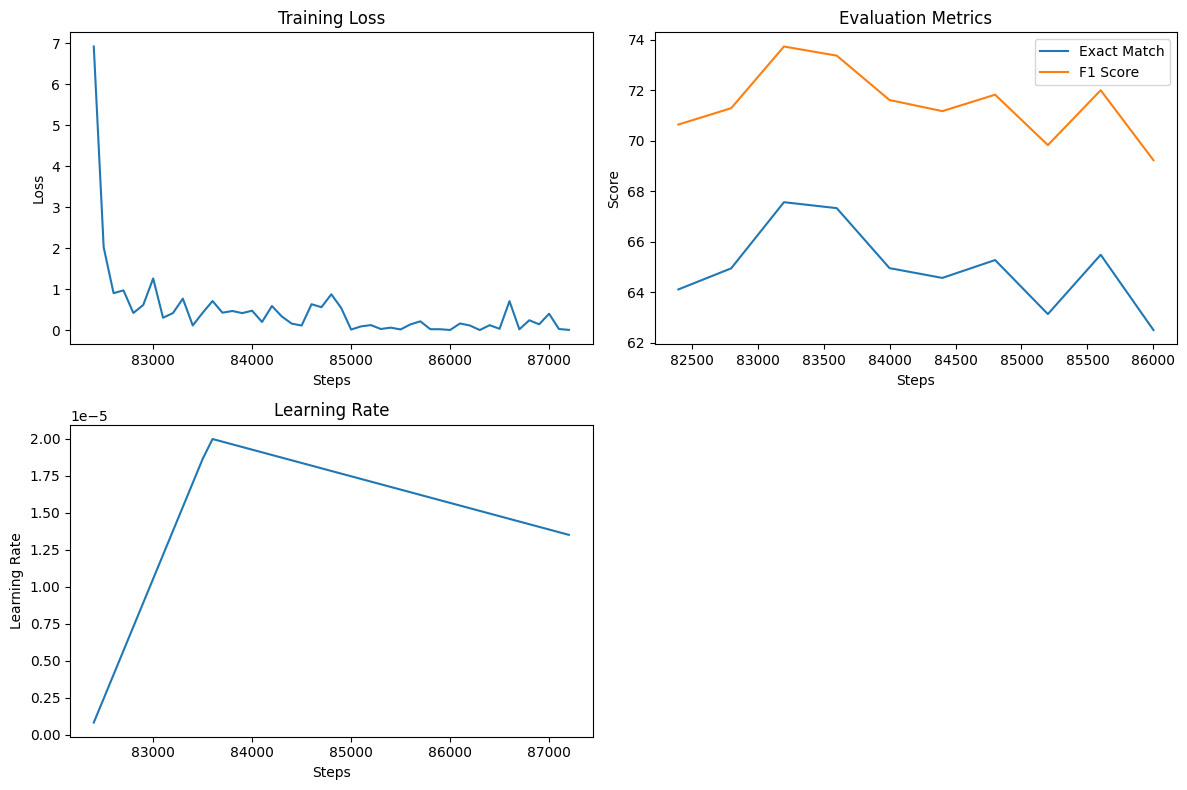

In [ ]:
plt.figure(figsize=(12, 8))

# Plot training loss
plt.subplot(2, 2, 1)
plt.plot(metrics_history["steps"], metrics_history["training_loss"])
plt.title("Training Loss")
plt.xlabel("Steps")
plt.ylabel("Loss")

# Plot evaluation metrics
eval_steps = metrics_history["steps"][::len(metrics_history["steps"])//len(metrics_history["exact"])]
if len(eval_steps) > len(metrics_history["exact"]):
    eval_steps = eval_steps[:len(metrics_history["exact"])]

plt.subplot(2, 2, 2)
plt.plot(eval_steps, metrics_history["exact"], label="Exact Match")
plt.plot(eval_steps, metrics_history["f1"], label="F1 Score")
plt.title("Evaluation Metrics")
plt.xlabel("Steps")
plt.ylabel("Score")
plt.legend()

# Plot learning rate
plt.subplot(2, 2, 3)
plt.plot(metrics_history["steps"], metrics_history["learning_rate"])
plt.title("Learning Rate")
plt.xlabel("Steps")
plt.ylabel("Learning Rate")

plt.tight_layout()
plt.savefig(os.path.join(MODEL_DIR, "BERT_training_progress.png"))  # Changed to MODEL_DIR
plt.show()

In [22]:
# Load the best model from checkpoint-84000
best_model_path = os.path.join(MODEL_DIR, "checkpoint-84000")
print(f"Loading best model from: {best_model_path}")

if os.path.exists(best_model_path):
    best_model = BertForQuestionAnswering.from_pretrained(best_model_path)
    best_model.to(device)
    
    # Evaluate the best model
    print("Evaluating best model...")
    best_model.eval()
    
    eval_metrics = evaluate_model(best_model, validation_dataset, squad_dataset["validation"])
    
    print(f"Best Model Results:")
    print(f"Exact Match: {eval_metrics['exact']:.2f}")
    print(f"F1 Score: {eval_metrics['f1']:.2f}")
    
    # Save final evaluation metrics
    with open(os.path.join(MODEL_DIR, "final_metrics.json"), 'w') as f:
        json.dump(eval_metrics, f, indent=2)
else:
    print(f"Best model checkpoint not found at: {best_model_path}")
    print(f"Contents of MODEL_DIR ({MODEL_DIR}):")
    print(os.listdir(MODEL_DIR))

Loading best model from: /Users/seanhall/Desktop/NLPFinalProject/BERT/bert_squad2_finetuned/checkpoint-84000
Evaluating best model...


Evaluating:   1%|          | 17/1517 [00:11<17:00,  1.47it/s]


KeyboardInterrupt: 